# 2 - Visualization
Overlaying student GPS submissions on top of the physical amphitheater footprint polygons.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import os

## 1. Load Student GPS Data
We load the dataset and reverse the row order (newest-first export).

In [2]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\api_submission_v2.csv'
df = pd.read_csv(csv_path)

# Reverse order (export is newest-first)
df = df.iloc[::-1].reset_index(drop=True)

print(f"Loaded {len(df)} submissions.")
df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].head()

Loaded 7179 submissions.


,amphitheatre,latitude_mean,longitude_mean,is_outside
0,Amphi 4,36.688401,2.866079,False
1,Amphi 4,36.688401,2.866079,False
2,Amphi 4,36.688401,2.866079,False
3,Amphi 4,36.688401,2.866080,False
4,Amphi 4,36.688405,2.866167,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7179 entries, 0 to 7178
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   7179 non-null   int64  
 1   year                 7179 non-null   int64  
 2   section              0 non-null      float64
 3   user                 867 non-null    object 
 4   amphitheatre         7179 non-null   object 
 5   module               6312 non-null   object 
 6   seat_block           6025 non-null   object 
 7   seat_row             6025 non-null   float64
 8   seat_column          6025 non-null   float64
 9   latitude_mean        7179 non-null   float64
 10  longitude_mean       7179 non-null   float64
 11  accuracy_mean        7179 non-null   float64
 12  gps_variance         7179 non-null   float64
 13  is_outside           7179 non-null   bool   
 14  sample_count         7179 non-null   int64  
 15  raw_gps_readings     7179 non-null   o

In [5]:
# Standardize amphitheatretheater labels
# Keep amphitheatre 1-8, change everything else to "Outside"
valid_amphis = [f"Amphi {i}" for i in range(1, 9)]  # Amphi 1 through Amphi 8

print("Before standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Replace non-standard labels with "Outside"
df['amphitheatre'] = df['amphitheatre'].apply(lambda x: x if x in valid_amphis else "Outside")

print("\nAfter standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Verify we have the expected classes
expected_classes = valid_amphis + ["Outside"]
actual_classes = sorted(df['amphitheatre'].unique())
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")
print(f"Classes match: {set(expected_classes) == set(actual_classes)}")

Before standardization:
Unique amphitheater labels: ['Amphi 4' 'Amphi 1' 'Amphi 3 door 1 ' 'Amphi 3 door 2 ' 'Amphi 3'
 'Salle d’études' "Salle d'études" 'maalma3' 'Amphi 5' 'Spot ' 'Amphi 2'
 'Amphi 6' 'SkillnTell Spot ' 'Amphi 7' 'Outside' 'Mdpres end tarek'
 'Nasro' 'Hfgnffn' 'nasro ' 'outside' 'dorm' 'mazalni end tarek'
 'end tarek' 'room' 'School entry' 'lab 8']
Label counts:
amphitheatre
Amphi 2              2565
Amphi 5              1227
Amphi 6               774
Amphi 4               741
Outside               658
Amphi 1               594
Amphi 3               211
Amphi 7               122
Nasro                 100
Mdpres end tarek       46
maalma3                33
Salle d'études         20
SkillnTell Spot        20
Salle d’études         10
Spot                   10
Amphi 3 door 1         10
Amphi 3 door 2         10
Hfgnffn                10
nasro                  10
outside                 2
dorm                    1
mazalni end tarek       1
end tarek               1
room 

## 2. Amphitheater Landmarks (Polygons)
Physical boundaries for the 4 amphitheater spaces.

In [6]:
amphi_corners = {
    "Amphi 1/5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 2/6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
    "Amphi 3/7": [
        (36.6881935, 2.8661324),  # top-left
        (36.6881954, 2.8662759),  # top-right
        (36.6880368, 2.8663122),  # bottom-right
        (36.6880252, 2.8661318),  # bottom-left
    ],
    "Amphi 4/8": [
        (36.6881693, 2.8658652),  # top-left
        (36.6881817, 2.8660131),  # top-right
        (36.6880179, 2.8660490),  # bottom-right
        (36.6880075, 2.8658649),  # bottom-left
    ],
}

## 3. Analysis Plot
Visualizing submissions on top of physical basins to check for drift and accuracy.

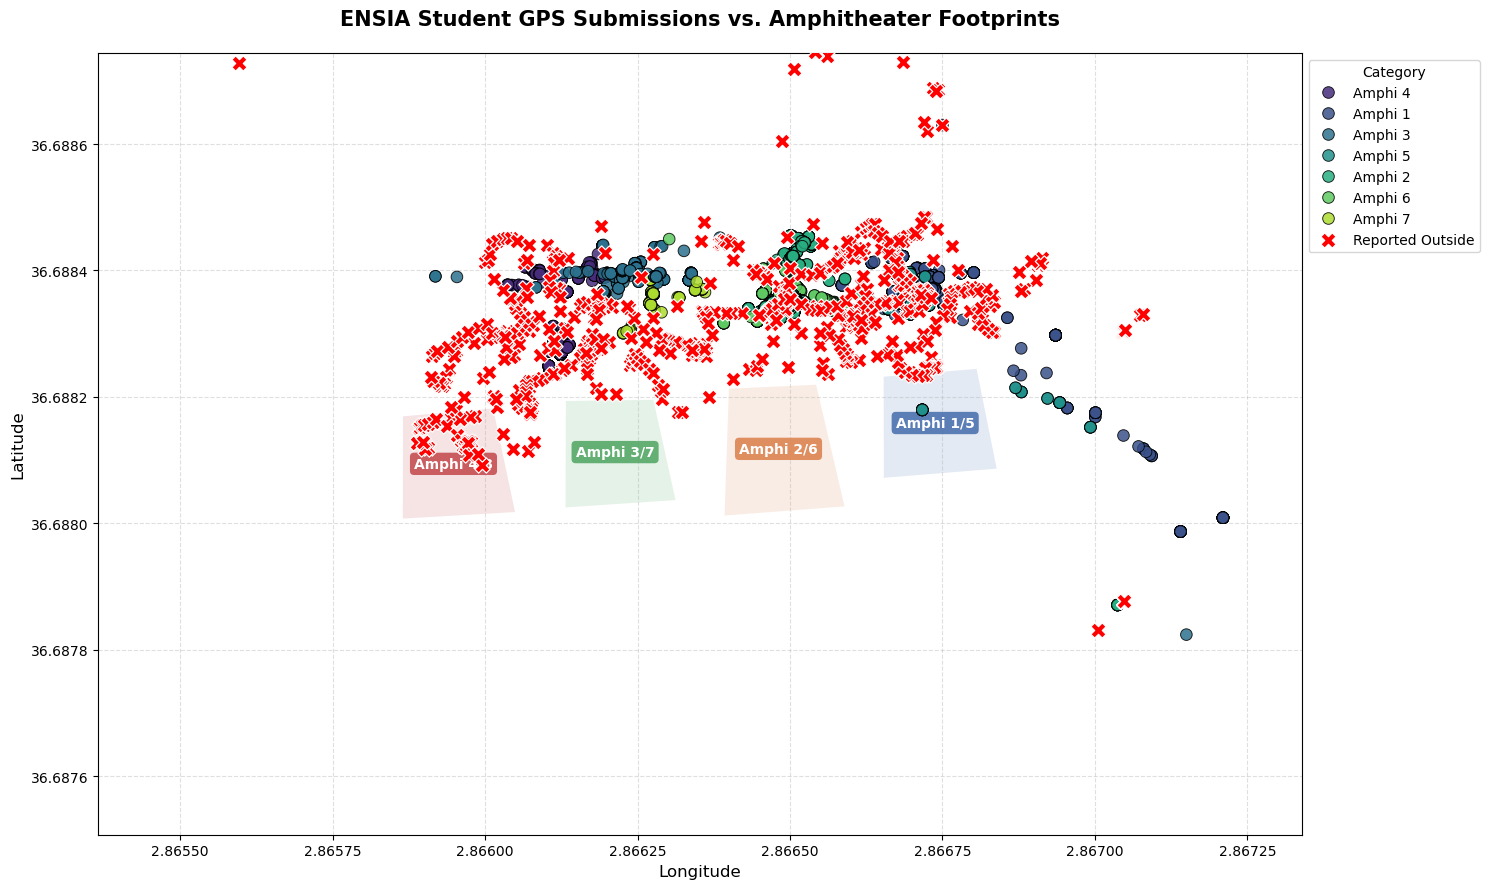

In [7]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
amphi_names = list(amphi_corners.keys())

fig, ax = plt.subplots(figsize=(15, 9))

# 1. Plot Polygons (Amphi Areas)
patches = []
for (name, corners), color in zip(amphi_corners.items(), colors):
    # Convert (lat, lon) -> (lon, lat) for (x, y) coordinates
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

    # Label the amphi at center
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    ax.text(cx, cy, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9))

collection = PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1)
ax.add_collection(collection)

# 2. Scatter Student Submissions
# We differentiate indoor submissions by claimed Amphi and mark 'IsOutside' separately
df_indoor = df[df['is_outside'] == False]
df_outdoor = df[df['is_outside'] == True]

scatter = sns.scatterplot(
    data=df_indoor, x='longitude_mean', y='latitude_mean', hue='amphitheatre', 
    marker='o', s=70, alpha=0.85, edgecolor='black', palette='viridis', ax=ax, zorder=3
)

sns.scatterplot(
    data=df_outdoor, x='longitude_mean', y='latitude_mean', 
    marker='X', s=120, color='red', label='Reported Outside', ax=ax, zorder=4
)

# Axis formatting
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('ENSIA Student GPS Submissions vs. Amphitheater Footprints', fontsize=15, fontweight='bold', pad=20)
ax.ticklabel_format(useOffset=False)
ax.grid(True, linestyle='--', alpha=0.4)

# Legend
ax.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Set limits based on polygons with small buffer
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

plt.tight_layout()
plt.savefig('ensia_gps_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   3654 non-null   float64
 1   year                 3360 non-null   float64
 2   section              0 non-null      float64
 3   user                 952 non-null    object 
 4   amphitheatre         3654 non-null   object 
 5   module               2996 non-null   object 
 6   seat_block           2528 non-null   object 
 7   seat_row             2528 non-null   float64
 8   seat_column          2528 non-null   float64
 9   latitude_mean        3654 non-null   float64
 10  longitude_mean       3654 non-null   float64
 11  accuracy_mean        3360 non-null   float64
 12  gps_variance         3360 non-null   float64
 13  is_outside           3654 non-null   bool   
 14  sample_count         3654 non-null   float64
 15  raw_gps_readings     3654 non-null   o

In [36]:
df = df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']]

In [37]:
df.columns

Index(['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside'], dtype='object')

In [38]:
df['amphitheatre'].unique()

array(['Amphi 6', 'Amphi 5', 'Amphi 1', 'Outside', 'Amphi 2',
       'Mdpres end tarek', 'Nasro', 'Hfgnffn', 'nasro ', 'outside',
       'Amphi 7', 'dorm', 'mazalni end tarek', 'end tarek', 'room',
       'Amphi 4', 'School entry', 'lab 8', 'Amphi 3'], dtype=object)

In [39]:
import re

valid_amphis = {f"Amphi {i}" for i in range(1, 9)}

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x.strip() if isinstance(x, str) else x
)

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x if x in valid_amphis else "Outside"
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\2511729114.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amphitheatre'] = df['amphitheatre'].apply(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\2511729114.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amphitheatre'] = df['amphitheatre'].apply(


In [40]:
df['amphitheatre'].unique()

array(['Amphi 6', 'Amphi 5', 'Amphi 1', 'Outside', 'Amphi 2', 'Amphi 7',
       'Amphi 4', 'Amphi 3'], dtype=object)

In [42]:
df['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2412
Outside     832
Amphi 6     170
Amphi 5     137
Amphi 1      89
Amphi 7      12
Amphi 4       1
Amphi 3       1
Name: count, dtype: int64

In [ ]:
amphi_group_map = {
    "Amphi 1": "Amphi 1/5",
    "Amphi 5": "Amphi 1/5",
    "Amphi 2": "Amphi 2/6",
    "Amphi 6": "Amphi 2/6",
    "Amphi 3": "Amphi 3/7",
    "Amphi 7": "Amphi 3/7",
    "Amphi 4": "Amphi 4/8",
    "Amphi 8": "Amphi 4/8",
}

df['amphi_group'] = df['amphitheatre'].map(amphi_group_map).fillna("Outside")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\3360732490.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amphi_group'] = df['amphitheatre'].map(amphi_group_map).fillna("Outside")


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def plot_amphi_group(df, group_name):
    fig, ax = plt.subplots(figsize=(10, 8))

    # =========================
    # 1. Draw all polygons
    # =========================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

        cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
        ax.text(
            cx, cy, name,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9)
        )

    ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

    # =========================
    # 2. Filter data for this group
    # =========================
    subset = df[df['amphi_group'] == group_name]

    if group_name == "Outside":
        sns.scatterplot(
            data=subset,
            x='longitude_mean',
            y='latitude_mean',
            color='red',
            marker='X',
            s=120,
            ax=ax,
            label="Outside",
            zorder=3
        )
    else:
        sns.scatterplot(
            data=subset,
            x='longitude_mean',
            y='latitude_mean',
            color='blue',
            edgecolor='black',
            s=70,
            ax=ax,
            label=group_name,
            zorder=3
        )

    # =========================
    # 3. Formatting
    # =========================
    ax.set_title(f"GPS Points - {group_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.4)

    # same bounds for all plots
    all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
    ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
    ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

    ax.legend()
    plt.tight_layout()
    plt.show()

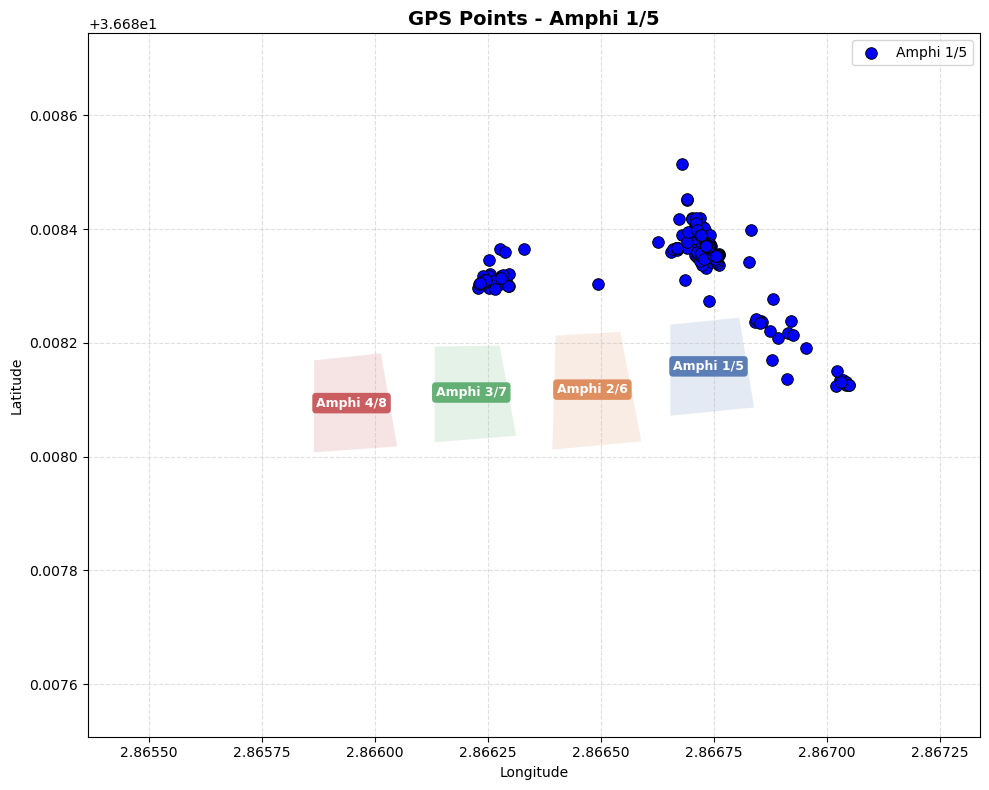

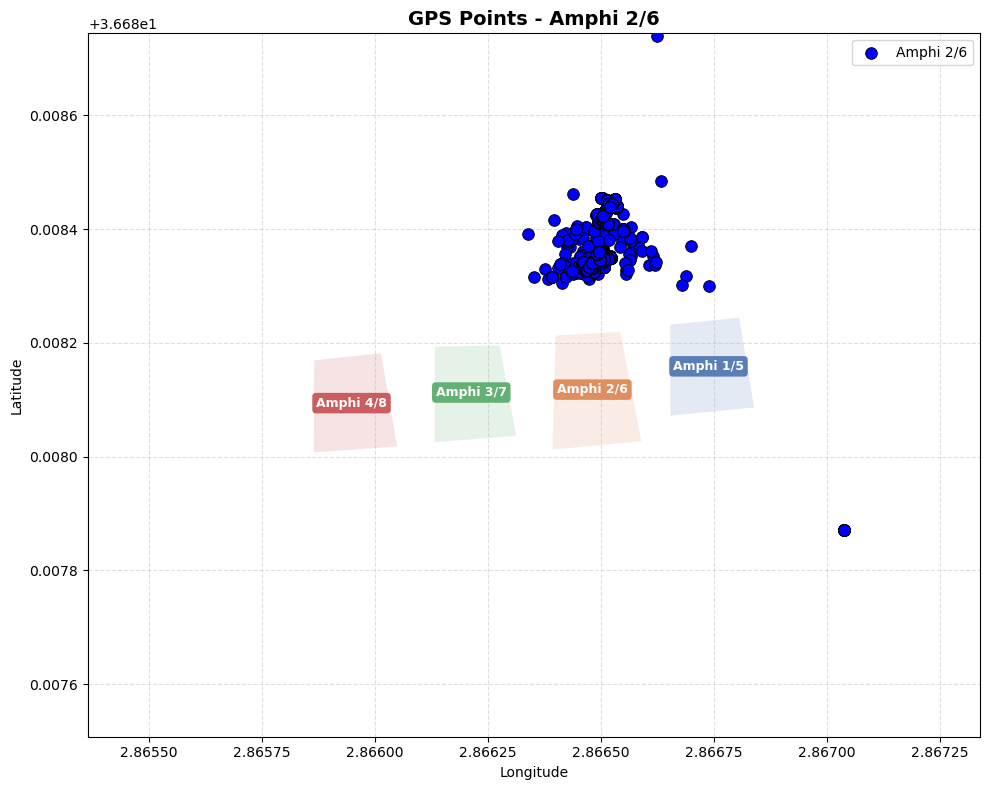

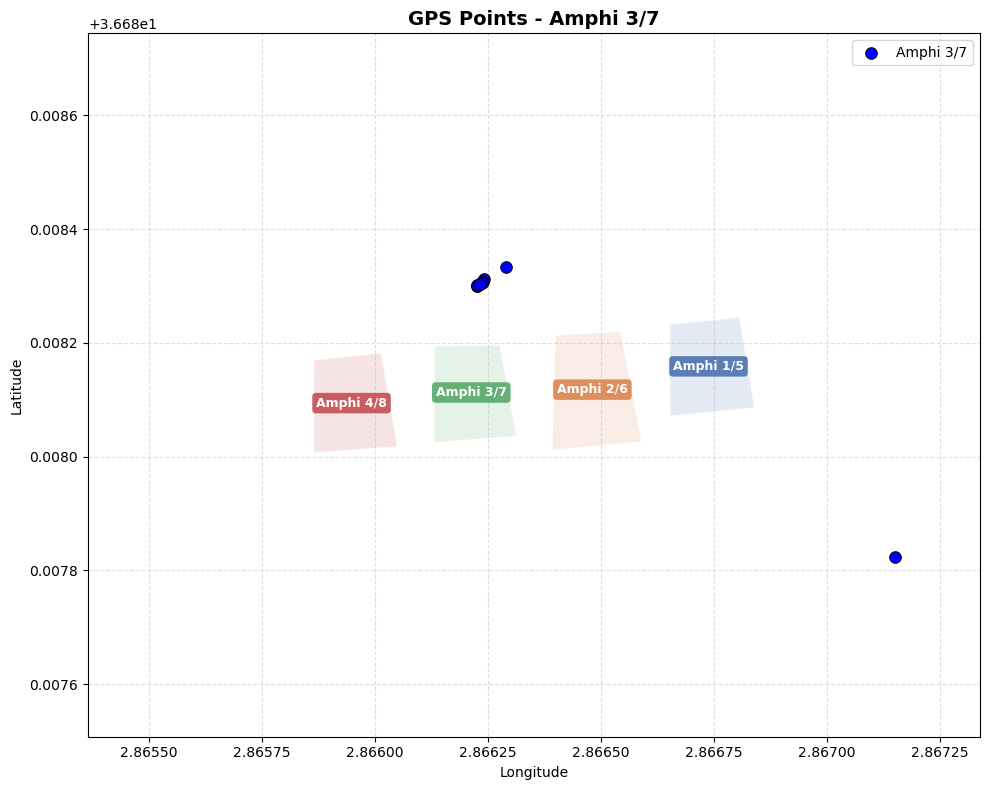

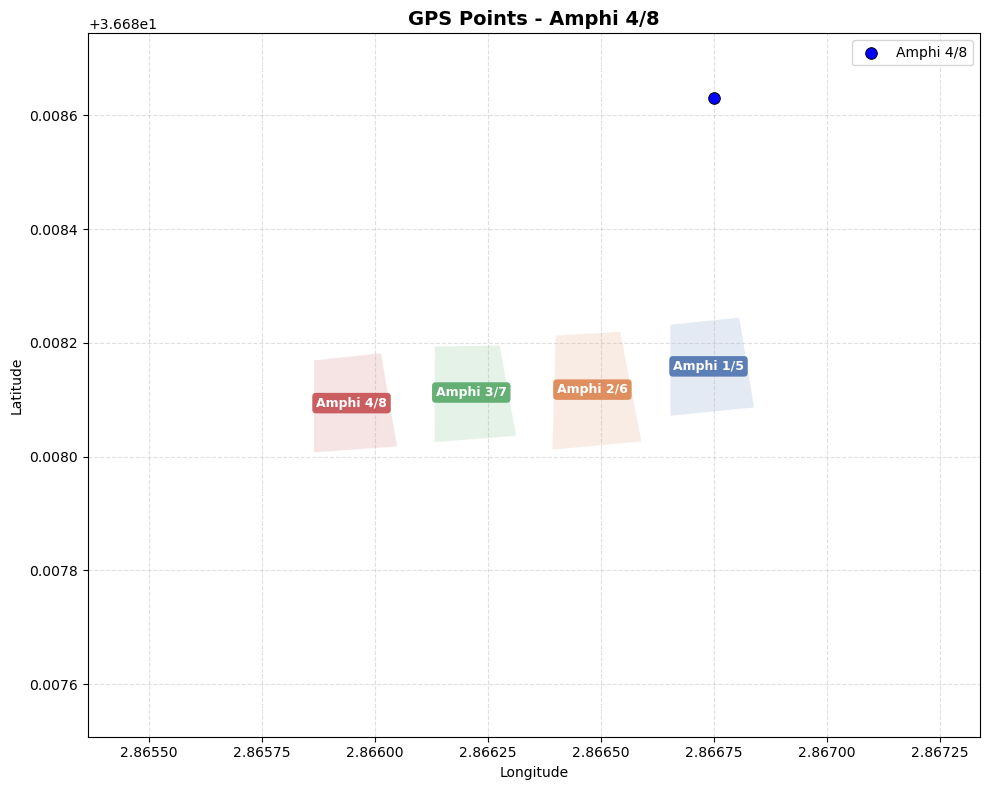

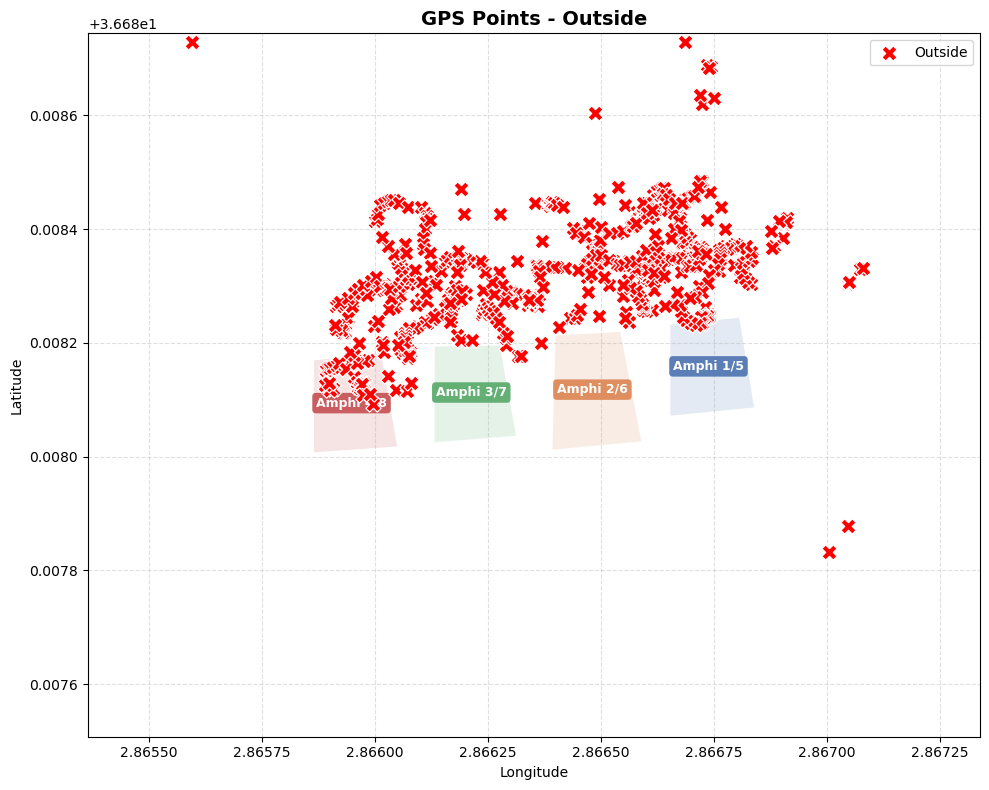

In [47]:
groups = [
    "Amphi 1/5",
    "Amphi 2/6",
    "Amphi 3/7",
    "Amphi 4/8",
    "Outside"
]

for g in groups:
    plot_amphi_group(df, g)

In [48]:
valid_amphis = {f"Amphi {i}" for i in range(1, 9)}

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x.strip() if isinstance(x, str) else x
)

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x if x in valid_amphis else "Outside"
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\219565670.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amphitheatre'] = df['amphitheatre'].apply(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\219565670.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amphitheatre'] = df['amphitheatre'].apply(


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def plot_single_amphi(df, amphi_name):
    fig, ax = plt.subplots(figsize=(10, 8))

    # =========================
    # 1. Draw all polygons
    # =========================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

        cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
        ax.text(
            cx, cy, name,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9)
        )

    ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

    # =========================
    # 2. Filter ONLY this amphi
    # =========================
    subset = df[df['amphitheatre'] == amphi_name]

    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color='#1f77b4',
        edgecolor='black',
        s=70,
        alpha=0.85,
        ax=ax,
        label=amphi_name,
        zorder=3
    )

    # =========================
    # 3. Formatting
    # =========================
    ax.set_title(f"GPS Points - {amphi_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.4)

    # same fixed bounds
    all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
    ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
    ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

    ax.legend()
    plt.tight_layout()
    plt.show()

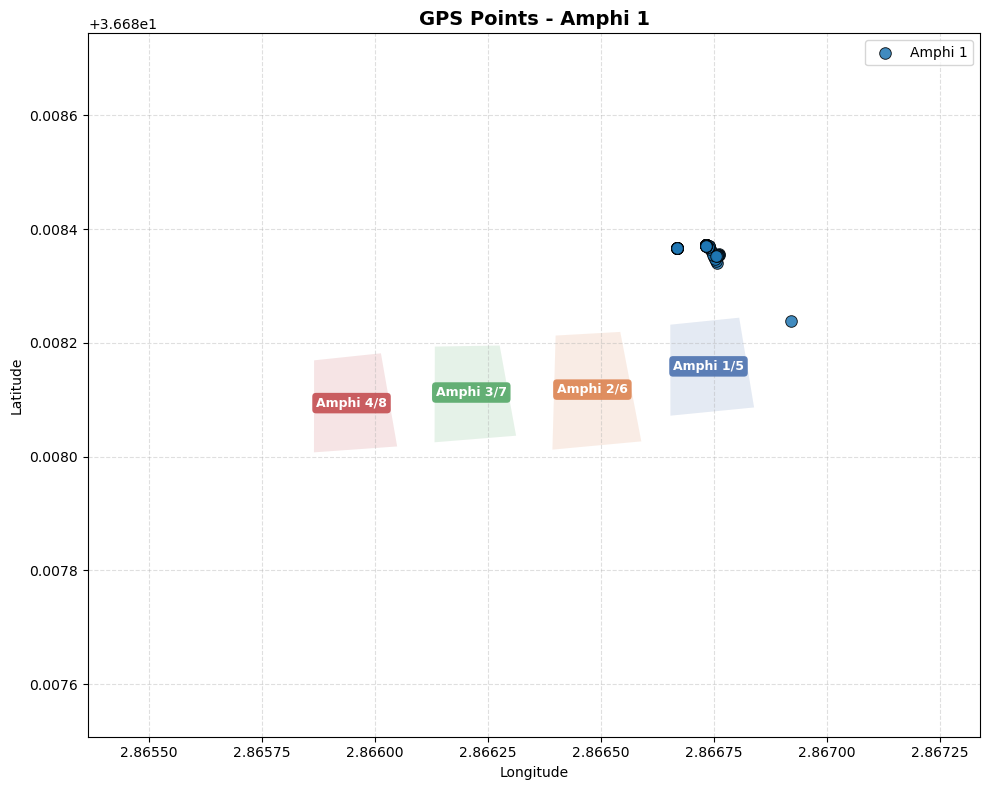

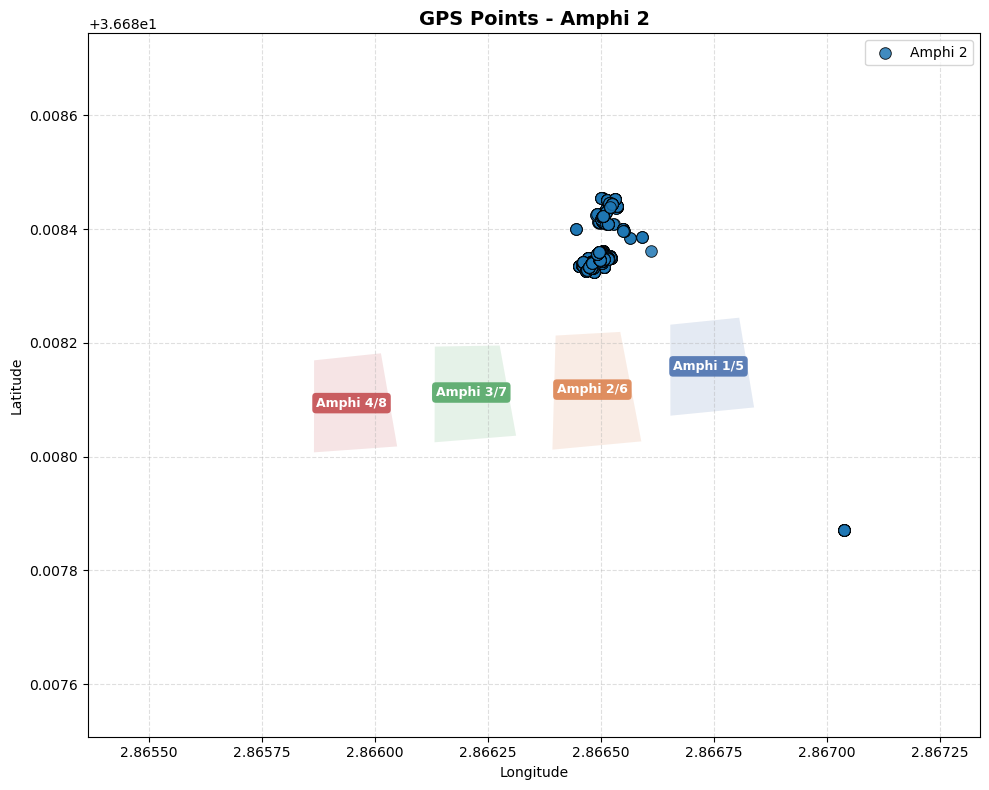

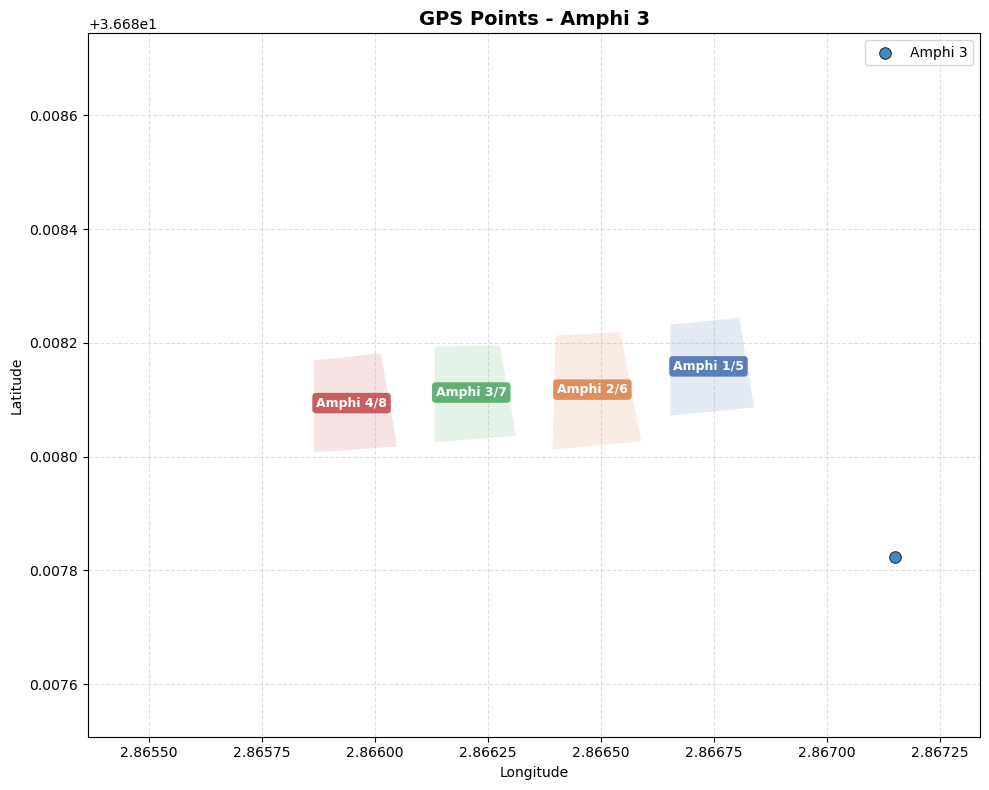

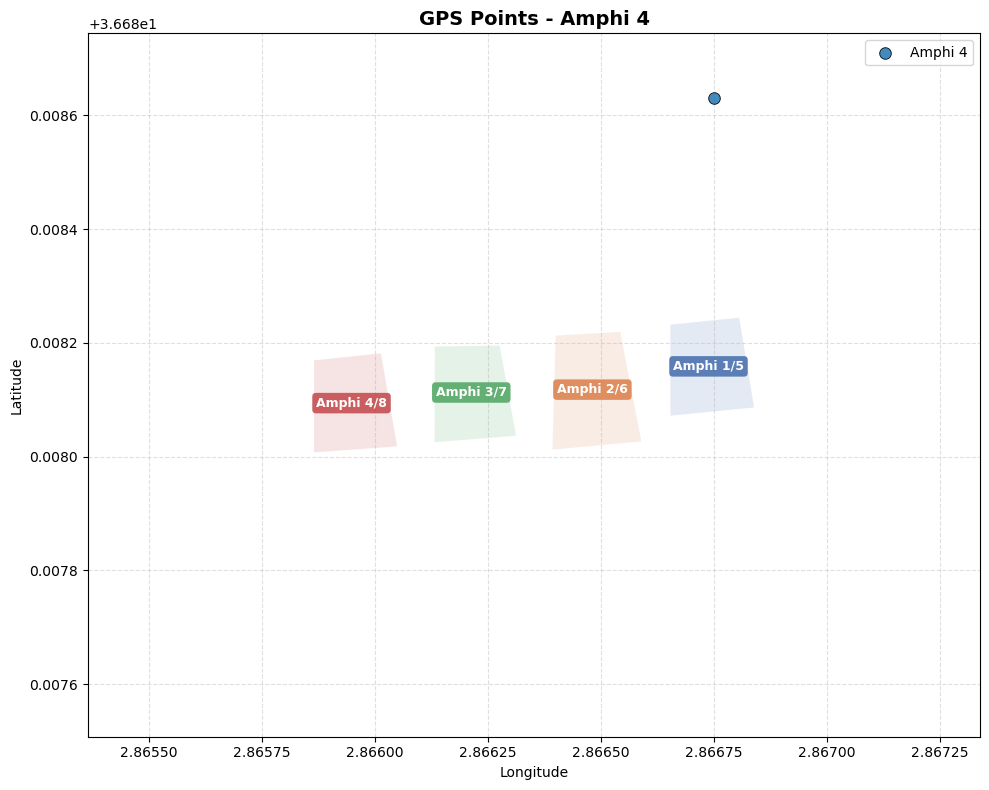

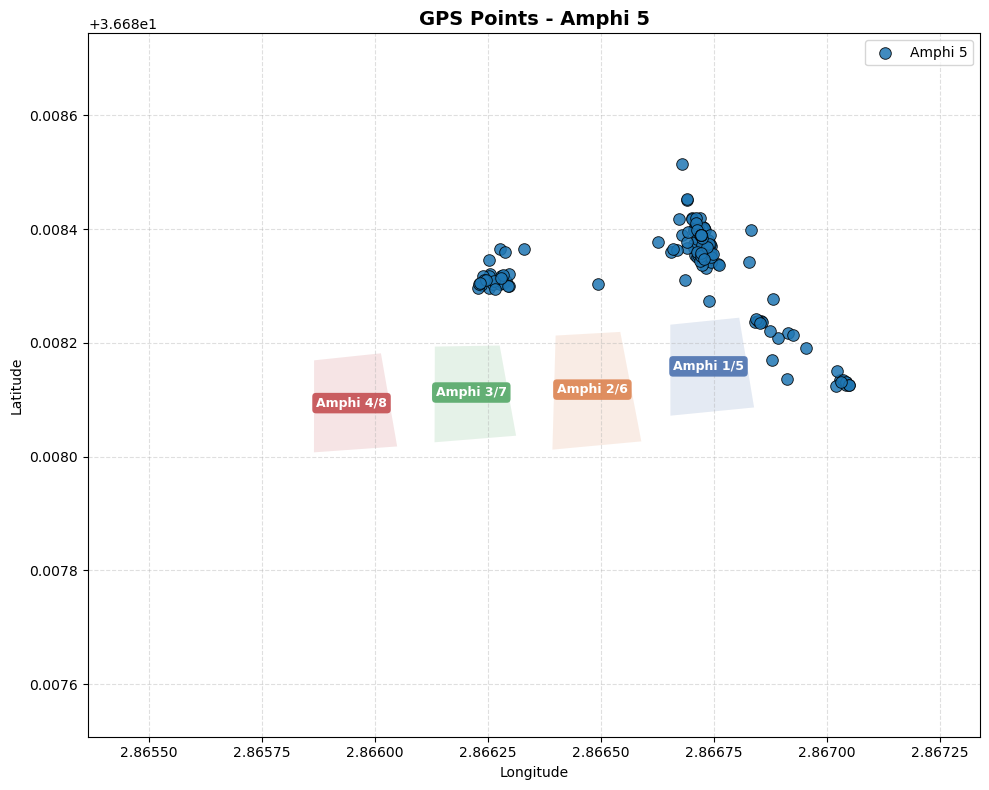

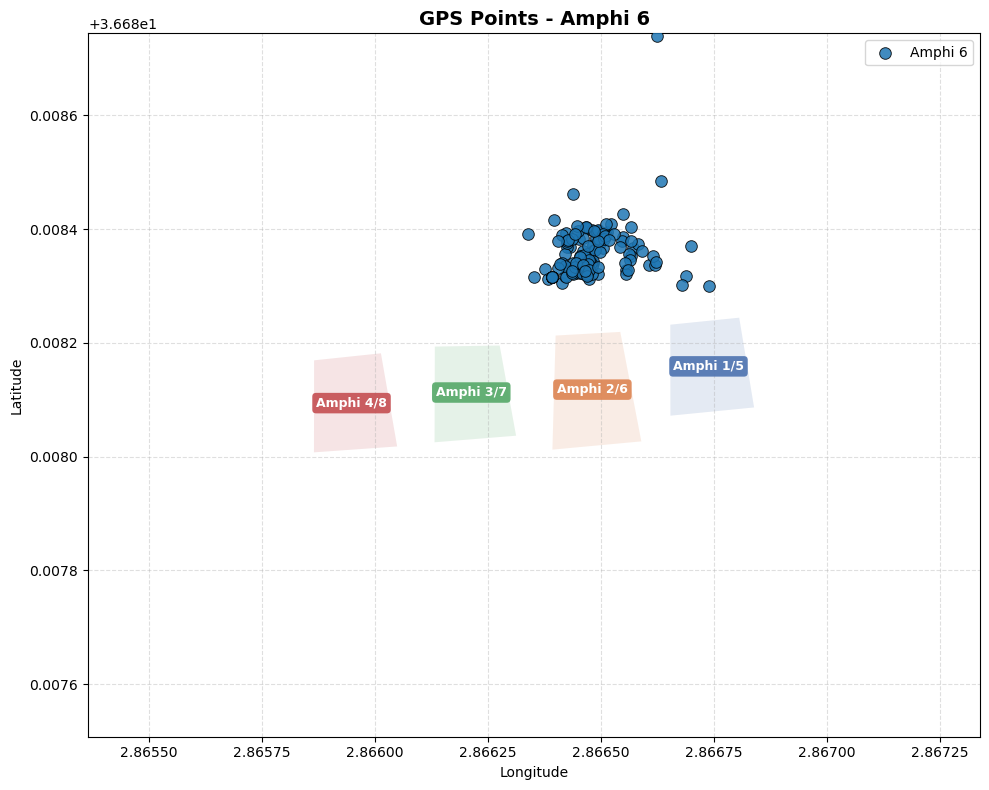

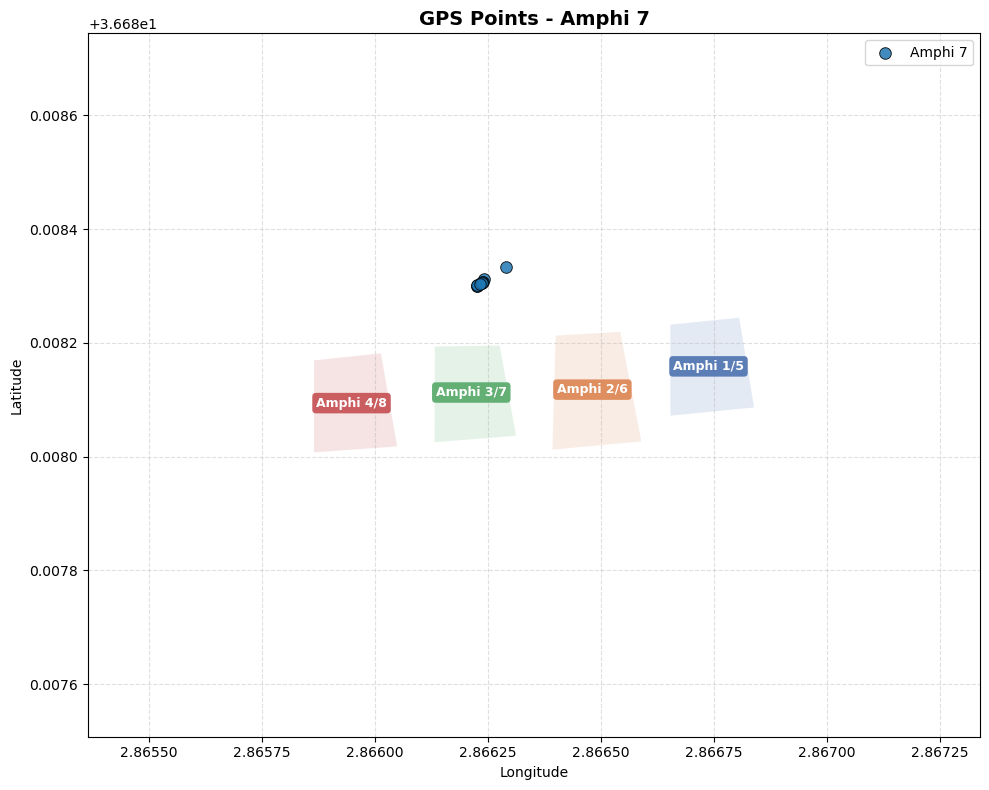

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4876\4153984213.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


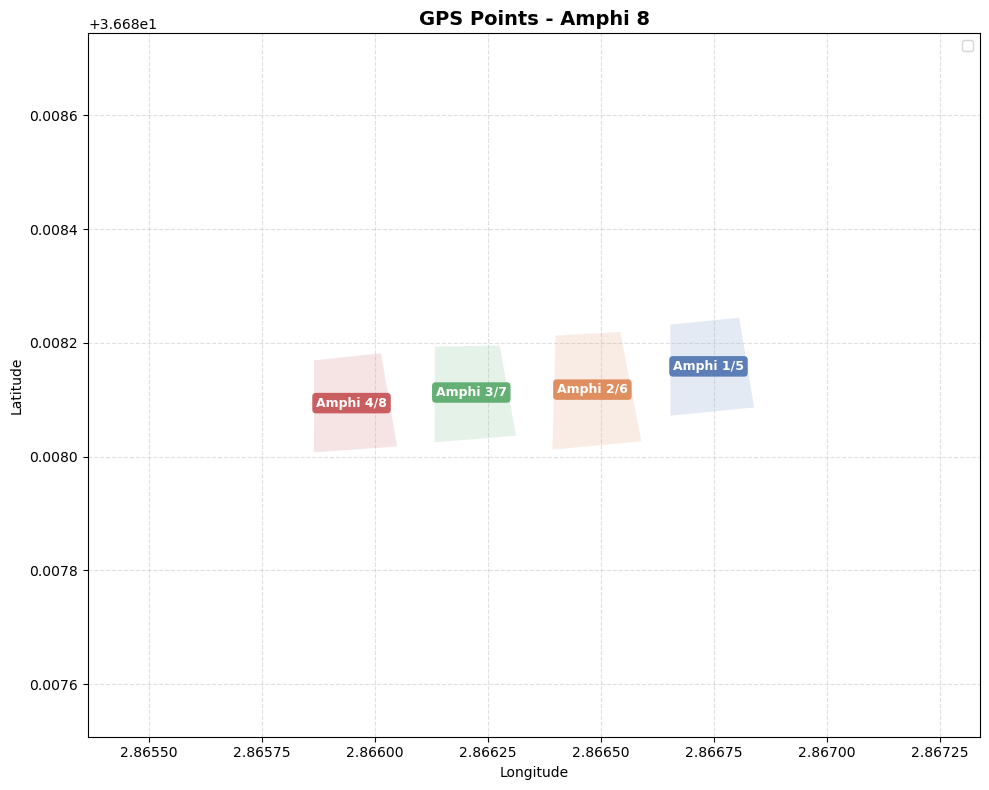

In [50]:
for i in range(1, 9):
    plot_single_amphi(df, f"Amphi {i}")